A credit card company wants to develop a model based on the history of data (Data.CSV). 

In [2]:
import pandas as pd
dataset = pd.read_csv('data/datad1.csv')
dataset

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
0,0.95822,3.4,8.2,53.0,47.0
1,0.85566,3.2,5.9,55.0,35.0
2,0.68025,3.2,9.3,41.0,32.0
3,0.25936,3.2,8.2,47.0,34.0
4,0.60447,3.8,10.0,75.0,33.0
...,...,...,...,...,...
1383,0.44549,5.5,8.0,51.0,41.0
1384,0.52466,4.9,6.5,63.0,37.0
1385,0.88197,3.9,6.2,54.0,36.0
1386,0.47336,3.5,7.3,61.0,34.0


In [5]:
# Function for descriptive statistics
def descriptive_stats(sample, field):
    
    if field not in sample.columns:
        return "Error: Field not found"
    
    data = sample[field]
    
    print("\n===== Descriptive Statistics for", field, "=====\n")
    
    print("Count                :", data.count())
    print("Mean                 :", data.mean())
    print("Median               :", data.median())
    print("Mode                 :", data.mode()[0] if not data.mode().empty else None)
    print("Minimum              :", data.min())
    print("Maximum              :", data.max())
    print("Range                :", data.max() - data.min())
    print("Variance             :", data.var())
    print("Standard Deviation   :", data.std())

# Make sure pandas is imported
import pandas as pd

dataset = pd.read_csv('data/datad1.csv')
descriptive_stats(dataset, "Grades")



===== Descriptive Statistics for Grades =====

Count                : 1388
Mean                 : 40.69164265129683
Median               : 35.0
Mode                 : 34.0
Minimum              : 32.0
Maximum              : 91.0
Range                : 59.0
Variance             : 89.6308745888648
Standard Deviation   : 9.467358374375864


In [7]:
dataset = pd.read_csv('data/datad1.csv')
sample_data = dataset.sample(n=150, random_state=1)
descriptive_stats(sample_data, "Grades")



===== Descriptive Statistics for Grades =====

Count                : 150
Mean                 : 40.68666666666667
Median               : 35.0
Mode                 : 34.0
Minimum              : 32.0
Maximum              : 88.0
Range                : 56.0
Variance             : 104.5521700223712
Standard Deviation   : 10.22507555093708


In [9]:
dataset = pd.read_csv('data/datad1.csv')
n = 150
N = len(dataset)
k = N // n
sample_data = dataset.iloc[::k]
 
sample_data = sample_data.head(n)

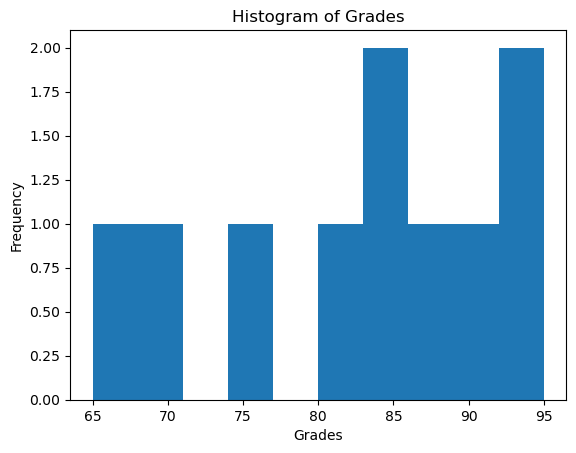

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
plt.hist(grades)
plt.title("Histogram of Grades")
plt.xlabel("Grades")
plt.ylabel("Frequency")
plt.show()

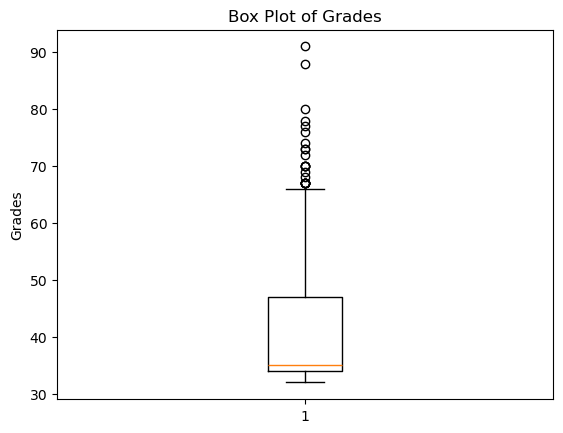

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
dataset = pd.read_csv('data/datad1.csv')
grades = dataset["Grades"]
plt.figure()
plt.boxplot(grades)
plt.title("Box Plot of Grades")
plt.ylabel("Grades")
plt.show()


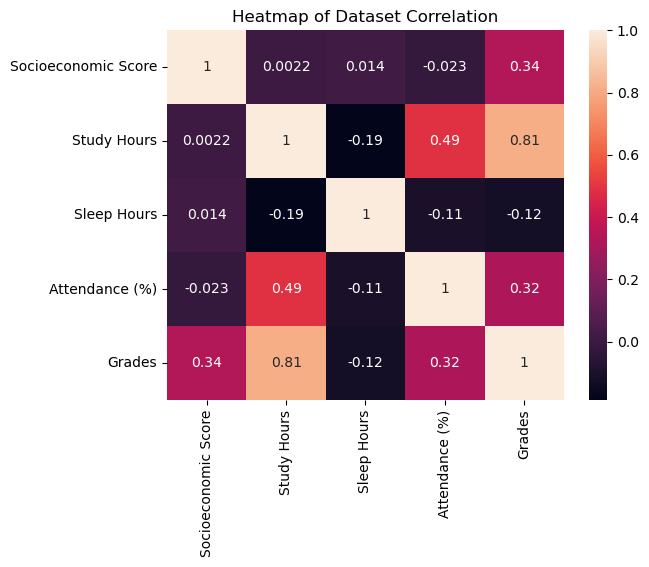

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
correlation = dataset.corr()
sns.heatmap(correlation, annot=True)
plt.title("Heatmap of Dataset Correlation")
plt.show()


In [19]:
from scipy.stats import pearsonr, spearmanr, chi2_contingency
 
dataset = pd.read_csv('data/datad1.csv')
 
independent_var = dataset["Study Hours"]
dependent_var = dataset["Grades"]
 
pearson_corr, p_value_p = pearsonr(independent_var, dependent_var)
 
print("\n=== Pearson Correlation ===")
print("Correlation:", pearson_corr)
print("P-value    :", p_value_p)
 
spearman_corr, p_value_s = spearmanr(independent_var, dependent_var)
 
print("\n=== Spearman Correlation ===")
print("Correlation:", spearman_corr)
print("P-value    :", p_value_s)
dataset["Grade_Category"] = pd.cut(dataset["Grades"],
                                  bins=[0, 70, 100],
                                  labels=["Low", "High"])
 
dataset["Study_Category"] = pd.cut(dataset["Study Hours"],
                                  bins=3,
                                  labels=["Low", "Medium", "High"])
 
contingency_table = pd.crosstab(dataset["Study_Category"],
                               dataset["Grade_Category"])
 
chi2, p, dof, expected = chi2_contingency(contingency_table)
 
print("\n=== Chi-Square Test ===")
print("Chi2 value :", chi2)
print("P-value    :", p)



=== Pearson Correlation ===
Correlation: 0.8108066169441057
P-value    : 0.0

=== Spearman Correlation ===
Correlation: 0.707309709045902
P-value    : 4.9482613837952085e-211

=== Chi-Square Test ===
Chi2 value : 60.53715676357187
P-value    : 7.153579924402099e-14


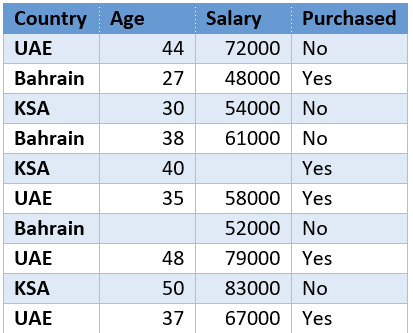

Before developing a model, it has to pre-process the historical data. Pre-processing the historical data involves several steps, such as: <br>

1.	Import libraries: Import the necessary libraries for data manipulation and preprocessing, such as pandas, numpy, and scikit-learn.<br>
2.	Load data: Load the dataset into a suitable data structure, such as a pandas DataFrame or a numpy array.<br>
3.	Data cleaning: Handle missing values using techniques like mean imputation.<br>
4.	Data transformation: Transform categorical data into numerical representations using techniques like one-hot encoding or label encoding.<br>
5.	Normalization and scaling: Normalize or scale numerical features to a common range, ensuring that all features have equal influence on the learning algorithm.<br>
6. Save preprocessed data: Save the preprocessed data for future use or for sharing with others.<br>

## Importing the libraries

In [3]:
# TODO: Import the required libraries (NumPy as np, Pandas as pd)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [4]:
# TODO: Load 'Data/Data.csv' into a DataFrame named 'dataset'
# TODO: Create the feature matrix X with all columns except the last (dataset.iloc[:, :-1].values)
# TODO: Create the target vector y with the last column (dataset.iloc[:, -1].values)

dataset = pd.read_csv('Data/Data.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [5]:
# TODO: Print the feature matrix X to inspect values

print(X)

[['UAE' 44.0 72000.0]
 ['Bahrain' 27.0 48000.0]
 ['KSA' 30.0 54000.0]
 ['Bahrain' 38.0 61000.0]
 ['KSA' 40.0 nan]
 ['UAE' 35.0 58000.0]
 ['Bahrain' nan 52000.0]
 ['UAE' 48.0 79000.0]
 ['KSA' 50.0 83000.0]
 ['UAE' 37.0 67000.0]]


In [6]:
# TODO: Print the target vector y to inspect values

print(y)

['No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes']


## Taking care of missing data

In [7]:
# TODO: Handle missing numerical values using SimpleImputer with strategy='mean'
# TODO: Fit the imputer on the numerical columns (e.g., X[:, 1:3]) and transform X accordingly

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X[:, 1:3])
X[:, 1:3] = imputer.transform(X[:, 1:3])

In [8]:
# TODO: Print the feature matrix X to inspect values

print(X)

[['UAE' 44.0 72000.0]
 ['Bahrain' 27.0 48000.0]
 ['KSA' 30.0 54000.0]
 ['Bahrain' 38.0 61000.0]
 ['KSA' 40.0 63777.77777777778]
 ['UAE' 35.0 58000.0]
 ['Bahrain' 38.77777777777778 52000.0]
 ['UAE' 48.0 79000.0]
 ['KSA' 50.0 83000.0]
 ['UAE' 37.0 67000.0]]


## Encoding categorical data

### Encoding the Independent Variable

In [9]:
# TODO: One-hot encode the categorical column(s) using ColumnTransformer with OneHotEncoder
# TODO: Pass through the remaining columns and assign the transformed array back to X

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [10]:
# TODO: Print the feature matrix X to inspect values

print(X)

[[0.0 0.0 1.0 44.0 72000.0]
 [1.0 0.0 0.0 27.0 48000.0]
 [0.0 1.0 0.0 30.0 54000.0]
 [1.0 0.0 0.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [0.0 0.0 1.0 35.0 58000.0]
 [1.0 0.0 0.0 38.77777777777778 52000.0]
 [0.0 0.0 1.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [0.0 0.0 1.0 37.0 67000.0]]


### Encoding the Dependent Variable

In [11]:
# TODO: Encode the dependent variable y using LabelEncoder (convert labels to 0/1)
# TODO: Assign the transformed vector back to y

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [12]:
# TODO: Print the target vector y to inspect values

print(y)

[0 1 0 0 1 1 0 1 0 1]


## Splitting the dataset into the Training set and Test set

In [13]:
# TODO: Split X and y into training and test sets using train_test_split
# TODO: Use test_size=0.2 and random_state=1 to match the lecture settings
# TODO: Produce X_train, X_test, y_train, y_test

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)